In [1]:
# Librerias
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

# import MUSE_utils.PPXF_astrometry_correction as ppxf_ac
import MUSE_utils.PPXF_class as ppxf_c
# import MUSE_utils.PPXF_extinction_correction as ppxf_ec
import MUSE_utils.PPXF_fitting as ppxf_f
import MUSE_utils.PPXF_helper as ppxf_h
# import MUSE_utils.PPXF_redshift_calculator as ppxf_rc
# import MUSE_utils.PPXF_zapping as ppxf_z

import joblib
from mpdaf.obj import Cube, WaveCoord#,WCS
from astroquery.ipac.ned import Ned
# from cutout_fits import download_panstarrs_fits, download_legacy_fits

d:\Universidad\Magister\MUSE PKS0745\MUSE_utils\PPXF_class.py:15: UserWarning: ⚠️ VorBin is deprecated and superseded by PowerBin https://pypi.org/project/powerbin/ 
  from vorbin.voronoi_2d_binning import voronoi_2d_binning


In [ ]:
# import ppxf.ppxf as PPXF
# import sys
# from pympler import asizeof
# print(asizeof.asizeof(stars))
# import pickle

# # Assuming 'pp' is your pPXF class object
# with open('ppxf_result.pkl', 'wb') as file:
#     pickle.dump(stars, file)

# # To load it back later:
# with open('ppxf_result.pkl', 'rb') as file:
#     STARS = pickle.load(file)

436971000


In [2]:
# Lectura de cubo
name_cube = "PKS0745_cube_wcscorr_ext-cor_small.fits"
hdu = fits.open(name_cube)
header_cube = hdu[0].header
header_data = hdu[1].header
crop_data = hdu[1].data # spectroXpixXpix
desv_data = hdu[2].data # spectroXpixXpix

# masked_data_skycube = np.where(crop_data>100, crop_data, 0)

# row, col = map(np.ravel, np.indices(crop_data.shape[-2:]))
# jm = np.argmax(np.nanmedian(crop_data, 0))
# x = (col - col[jm])
# print(jm,x,col)

Running Voronoi binning...


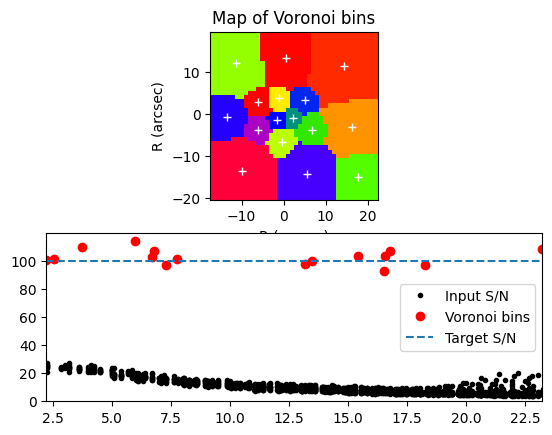

Setting up stellar templates...
reg_dim 2
0 / 15-------------------------------------
 Best Fit:       Vel     sigma        h3        h4
 comp.  0:       -52       222     0.115    -0.254
chi2/DOF: 0.6601; DOF: 2047; degree = 10; mdegree = 0
method = capfit; Jac calls: 6; Func calls: 33; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/150
 Best Fit:       Vel     sigma        h3        h4
 comp.  0:       -29       194    -0.026    -0.064
chi2/DOF: 0.2774; DOF: 1987; degree = 10; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 25; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/150
 Best Fit:       Vel     sigma
 comp.  0:       -29       194
chi2/DOF: 0.3031; DOF: 1983; degree = -1; mdegree = 8
method = capfit; Jac calls: 5; Func calls: 47; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/150
Voronoi bin 1 / 16; SPS: emiles; $\sigma$=194 km/s; S/N=29.4
##############################################################################
W

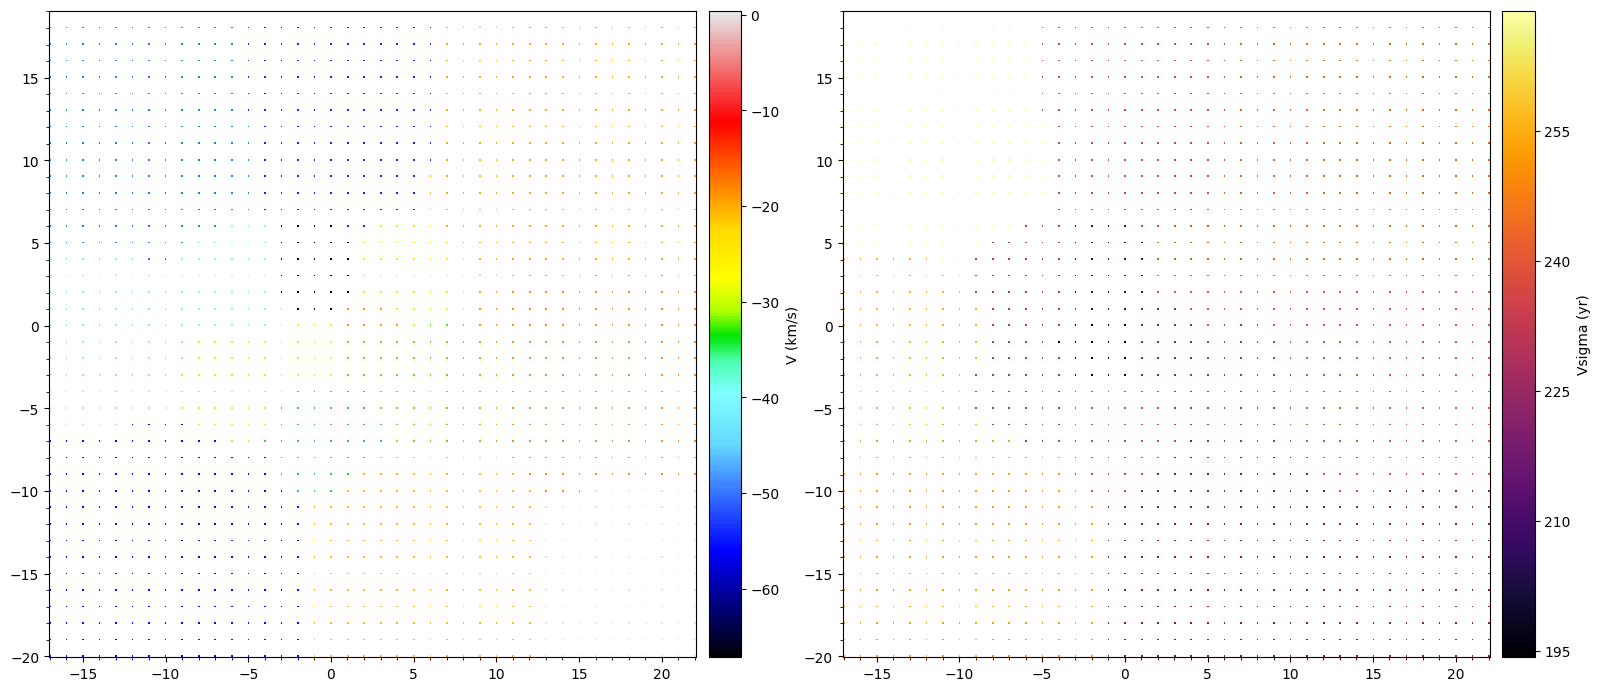

Saving stellar kinematic FITS maps...


In [3]:
gal_NED_id = "P0745"
vvcs= WCS(header_data)
coord = vvcs.pixel_to_world(header_data["NAXIS1"],header_data["NAXIS2"],0)

#print(coord[0])#<SkyCoord (ICRS): (ra, dec) in deg (116.87909416, -19.29329137)>
# result_table = Ned.query_object(gal_NED_id)
z = 0.1028
c = SkyCoord(ra=116.87909416*u.degree, dec=-19.29329137*u.degree, frame="icrs")

lam_range_temp = [4600, 7000]

s = ppxf_h.read_data_cube(name_cube, lam_range_temp, z)
s.outfolder = "./maps/"
s.start = [0, 200.]    # (km/s), starting guess for [V,sigma]

valid = np.isfinite(s.noise)
median_noise = np.nanmedian(s.noise[valid])
s.noise[~valid] = median_noise

valid = np.isfinite(s.signal)
median_s = np.nanmedian(s.signal[valid])
s.signal[~valid] = median_s

s.redshift = z

### 1. Voronoi binning and stellar kinematics
sk = ppxf_f.stellar_kinematics(
    s=s,
    target_sn=100,
    noise=s.noise,
    signal=s.signal,
    width_lines=1500,  # width to use to mask the emission lines
)

stars = sk.stellar_kinematics()
# ra_hms = c.ra.to_string(unit=u.hour, sep=('h', 'm', 's'), precision=4, pad=True)
# dec_dms = c.dec.to_string(unit=u.degree, sep=('d', 'm', 's'), precision=3, alwayssign=True, pad=True)

# cube_zapped = ppxf_z.Zapping.do_zapping(name_cube, header_data, desv_data, header_data)

In [ ]:
#print(asizeof.asizeof(fit_gas))

14669787528


In [4]:
fit_gas = ppxf_f.GasKinematicsFitter(
    s=s,
    sps=stars.sps,
    lam_gal=stars.lam_gal,
    velbin=stars.velbin,
    sigbin=stars.sigbin,
    h3=stars.h3,
    h4=stars.h4,
    bin_num=stars.bin_num,
    optimal_templates=stars.optimal_templates
)
#print(s.variance.shape, s.spectra.shape)

fit_gas.fit_cube_one_component(n_jobs=4)
fit_gas.save_all_emission_lines_one_component(header=s.header)

Emission lines included in gas templates:
['Hbeta' 'Halpha' '[SII]6716' '[SII]6731' '[NII]6548' '[NII]6584'
 '[OIII]4959' '[OIII]5007' 'HeII4687' 'HeI5876' '[NII]5755' '[NI]5198'
 '[NI]5200' '[OI]6300_d']


1-Gaussian gas fits: 100%|██████████| 1600/1600 [01:24<00:00, 18.84it/s]



Saving single-Gaussian maps for:
  → Halpha
  → Hbeta
  → HeI5876
  → HeII4687
  → [NII]5755
  → [NII]6548
  → [NII]6584
  → [NI]5198
  → [NI]5200
  → [OIII]4959
  → [OIII]5007
  → [OI]6300_d
  → [SII]6716
  → [SII]6731

✓ All emission-line maps saved.


In [ ]:
# # Run all spaxels two gaussians
fit_gas.fit_cube(n_jobs=2)

# Build flux maps, component maps, weighted velocities

# total de 85 minutos de ejecucion, tuve que cambiar el backend del parallel por threading, colapsaba por RAM
# se demora 1 hora de ejecucion con las optimizaciones de sin pp

Fitting gas spaxels:   0%|          | 0/1600 [00:00<?, ?it/s]

spaxel 3: galaxy.shape=(2591,), noise.shape=(2591,)spaxel 3: galaxy.shape=(2591,), noise.shape=(2591,)

 Best Fit:       Vel     sigma        h3        h4
 comp.  0:       -55       253    -0.087     0.065
 comp.  1:         8        53
chi2/DOF: 2.151; DOF: 2498; degree = -1; mdegree = 10
method = capfit; Jac calls: 2; Func calls: 28; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 10/15
Templates weights:
      28.8         0        11         0      9.17      26.1      33.3      35.5         0      79.6         0         0      33.6      62.5      10.2
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component           name        flux       err      V     sig
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Comp:  1             Hbeta_(1)      0.000       25.       8    53
Comp:  1            Halpha_(1)      10.96       24.       8    53
Comp:  1         [SII]6716_(1)      0.000       21.       8    53
Comp:  1         [SII]6731_(

Fitting gas spaxels:   0%|          | 4/1600 [00:04<28:12,  1.06s/it]

 Best Fit:       Vel     sigma        h3        h4
 comp.  0:       -55       253    -0.087     0.065
 comp.  1:        52         8
 comp.  2:      -479       249
chi2/DOF: 2.091; DOF: 2496; degree = -1; mdegree = 10
method = capfit; Jac calls: 8; Func calls: 122; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 14/29
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component           name        flux       err      V     sig
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Comp:  1             Hbeta_(1)      0.000       20.      52     8
Comp:  1            Halpha_(1)      0.000       18.      52     8
Comp:  1         [SII]6716_(1)      0.000       17.      52     8
Comp:  1         [SII]6731_(1)      0.000       14.      52     8
Comp:  1         [NII]6548_(1)      28.10       20.      52     8
Comp:  1         [NII]6584_(1)      12.37       17.      52     8
Comp:  1        [OIII]4959_(1)      30.52       21.      52     8
Comp: 

Fitting gas spaxels:   0%|          | 6/1600 [00:08<39:03,  1.47s/it]

...

 Best Fit:       Vel     sigma        h3        h4
 comp.  0:       -20       242    -0.004     0.087
 comp.  1:         1        61
 comp.  2:       -23       183
chi2/DOF: 1.763; DOF: 2496; degree = -1; mdegree = 10
method = capfit; Jac calls: 3; Func calls: 47; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 19/29
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component           name        flux       err      V     sig
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Comp:  1             Hbeta_(1)      0.000       55.       1    61
Comp:  1            Halpha_(1)      0.000       50.       1    61
Comp:  1         [SII]6716_(1)      58.95       48.       1    61
Comp:  1         [SII]6731_(1)      73.00       48.       1    61
Comp:  1         [NII]6548_(1)      0.000       47.       1    61
Comp:  1         [NII]6584_(1)      0.000       50.       1    61
Comp:  1        [OIII]4959_(1)      0.000       59.       1    61
Comp:  

Fitting gas spaxels: 100%|██████████| 1600/1600 [59:30<00:00,  2.23s/it]

 Best Fit:       Vel     sigma        h3        h4
 comp.  0:       -20       242    -0.004     0.087
 comp.  1:       -77        81
 comp.  2:        84       205
chi2/DOF: 1.678; DOF: 2496; degree = -1; mdegree = 10
method = capfit; Jac calls: 6; Func calls: 92; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 21/29
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component           name        flux       err      V     sig
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Comp:  1             Hbeta_(1)      164.4       48.     -77    81
Comp:  1            Halpha_(1)      410.8       44.     -77    81
Comp:  1         [SII]6716_(1)      199.6       45.     -77    81
Comp:  1         [SII]6731_(1)      182.0       47.     -77    81
Comp:  1         [NII]6548_(1)      136.2       43.     -77    81
Comp:  1         [NII]6584_(1)      362.5       44.     -77    81
Comp:  1        [OIII]4959_(1)      0.000       51.     -77    81
Comp:  

 Best Fit:       Vel     sigma        h3        h4
 comp.  0:       -20       242    -0.004     0.087
 comp.  1:         4       157
chi2/DOF: 1.672; DOF: 2498; degree = -1; mdegree = 10
method = capfit; Jac calls: 6; Func calls: 80; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 11/15
Templates weights:
      21.9       753  1.43e+03       547       471       504  1.51e+03         0       279       148         0         0         0       325       351
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component           name        flux       err      V     sig
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Comp:  1             Hbeta_(1)      752.7       47.       4   157
Comp:  1            Halpha_(1)      1425.       51.       4   157
Comp:  1         [SII]6716_(1)      547.2       48.       4   157
Comp:  1         [SII]6731_(1)      471.4       46.       4   157
Comp:  1         [NII]6548_(1)      503.9       49.       4   157


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [6]:
fit_gas.process_all_lines(s.header)


Processing line: Hbeta


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [15]:
a = [0,1,2,3,4,5,6,7,8,9,10,11,12,13]
b = np.array([a[i] for i in range(len(a))])
print(b)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
